In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/zomato.csv", on_bad_lines='skip', engine='python')

In [6]:

print(df.head())
print(df.info())
print(df.describe())

                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5  

In [7]:
print(df.columns)



Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


In [8]:
print(df.isnull().sum())

url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                           1921
votes                             0
phone                           280
location                          2
rest_type                        56
dish_liked                     7396
cuisines                         10
approx_cost(for two people)      37
reviews_list                      0
menu_item                         0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64


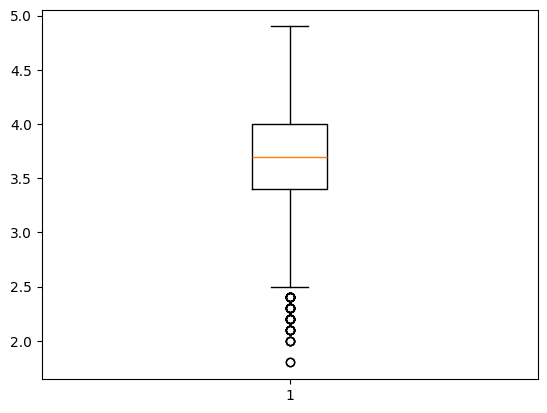

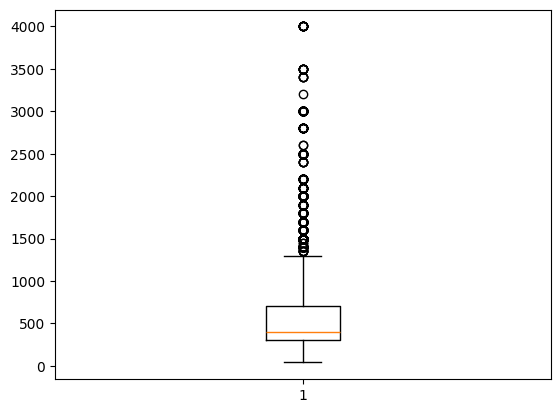

In [10]:
import matplotlib.pyplot as plt

df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

plt.boxplot(df["rate"].dropna())
plt.show()

plt.boxplot(df["approx_cost(for two people)"].dropna())
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()

df["cuisines"] = le.fit_transform(df["cuisines"].astype(str))
df["location"] = le.fit_transform(df["location"].astype(str))

scaler = StandardScaler()

df[["approx_cost(for two people)", "rate"]] = scaler.fit_transform(
    df[["approx_cost(for two people)", "rate"]]
)

print(df.head())

                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table      rate  votes                             phone  \
0          Yes        Yes  0.935750    775    080 42297555\r\n+91 9743772233   
1          Yes         No  0

In [14]:
df = df.dropna(subset=[
    "cuisines",
    "location",
    "approx_cost(for two people)",
    "rate"
])

df["target"] = (df["rate"] > 0).astype(int)

X = df[["cuisines", "location", "approx_cost(for two people)"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression()
lr.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

lr_auc = roc_auc_score(y_test, lr.predict(X_test))
rf_auc = roc_auc_score(y_test, rf.predict(X_test))

print("Logistic Regression AUC:", lr_auc)
print("Random Forest AUC:", rf_auc)

Logistic Regression AUC: 0.6345126771425817
Random Forest AUC: 0.8636652848741926


In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

params = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_res, y_res)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best ROC-AUC: 0.7867464375643716


SMOTE balances the classes by generating synthetic samples for the minority class. GridSearchCV then finds the best Random Forest parameters for improved performance.